# ECG experiments: how should the four recording sites be processed?

This notebook compares the current ECG model with a model that processes APEX, LLSB, LUSB, and RUSB separately before combining them into one patient prediction. It also records two later checks: simple heart-rate and recording-quality predictors, and 15-second training crops.

**Only development patients are used. Test patients are not loaded or used to choose models, epochs, thresholds, or experiments.**

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').is_dir():
    raise FileNotFoundError('Run this notebook from the project root or notebooks directory.')
sys.path.insert(0, str(PROJECT_ROOT))

from src.ecg_experiments import run_crop_comparison, run_five_fold, run_fold0
from src.ecg_feature_audit import run_audit
from src.ecg_cutoff_analysis import analyze_quality_groups, reanalyze_saved_predictions

OUTPUT_DIR = PROJECT_ROOT / 'analysis_outputs' / 'ecg_experiments'
MODEL_DIR = PROJECT_ROOT / 'models' / 'ecg_experiments'
print(f'Project: {PROJECT_ROOT}')

Project: E:\Deep Learning\CardioFusion


## Settings

The saved results load quickly. Training is off by default because the complete experiment takes several minutes and creates new checkpoints. Change only the switch for the run you need. Existing non-empty experiment folders are protected from accidental overwrite.

In [2]:
RUN_FOLD0 = False
RUN_FIVE_FOLD_SEED42 = False
RUN_FIVE_FOLD_SEED2026 = False
RUN_FEATURE_AUDIT = False
RUN_CROP_COMPARISON = False
RUN_CORRECTED_FIVE_FOLD_SEED42 = False
RUN_CORRECTED_FIVE_FOLD_SEED2026 = False
RUN_CORRECTED_CUTOFF_ANALYSIS = False

if RUN_FOLD0:
    run_fold0(PROJECT_ROOT)
if RUN_FIVE_FOLD_SEED42:
    run_five_fold(PROJECT_ROOT, seed=42)
if RUN_FIVE_FOLD_SEED2026:
    run_five_fold(PROJECT_ROOT, seed=2026)
if RUN_FEATURE_AUDIT:
    run_audit(PROJECT_ROOT)
if RUN_CROP_COMPARISON:
    run_crop_comparison(PROJECT_ROOT, seed=42)
if RUN_CORRECTED_FIVE_FOLD_SEED42:
    run_five_fold(PROJECT_ROOT, seed=42, run_label='corrected')
if RUN_CORRECTED_FIVE_FOLD_SEED2026:
    run_five_fold(PROJECT_ROOT, seed=2026, run_label='corrected')
if RUN_CORRECTED_CUTOFF_ANALYSIS:
    reanalyze_saved_predictions(PROJECT_ROOT, source='corrected')
    analyze_quality_groups(PROJECT_ROOT, source='corrected')
RUN_FLAGS = [RUN_FOLD0, RUN_FIVE_FOLD_SEED42, RUN_FIVE_FOLD_SEED2026, RUN_FEATURE_AUDIT, RUN_CROP_COMPARISON, RUN_CORRECTED_FIVE_FOLD_SEED42, RUN_CORRECTED_FIVE_FOLD_SEED2026, RUN_CORRECTED_CUTOFF_ANALYSIS]
print('Training controls checked. No training runs were requested.' if not any(RUN_FLAGS) else 'Requested run finished.')

Training controls checked. No training runs were requested.


## What changed?

| Model | How it handles the four sites | Final output |
|---|---|---|
| Current four-channel model | Mixes the four recordings in its first convolution | One HFrEF probability per patient |
| Separate-site model | Runs the same one-channel encoder on each site, joins the four summaries in the fixed site order, then classifies | One HFrEF probability per patient |

The sites remain part of the same patient. They are not counted as four patients, and their raw recordings are not joined into an artificial long signal.

For the five-fold comparison, fold *k* is scored, fold *(k+1) mod 5* chooses the epoch and cutoff, and the other three folds train the model. Therefore every reported scoring patient was separate from training and tuning.

## First check: original fold 0

The old checkpoint is replayed with its saved cutoff. Two new models are then trained side by side with the recorded notebook-2 settings. The old score is useful history, but the new training did not reproduce it exactly, so the new pair is the fair architecture comparison.

In [3]:
fold0 = pd.read_csv(OUTPUT_DIR / 'fold0_architecture_comparison.csv')
fold0_columns = ['architecture', 'auprc', 'auroc', 'recall', 'specificity', 'balanced_accuracy', 'f1', 'brier', 'parameter_count', 'training_seconds']
display(fold0.reindex(columns=fold0_columns).round(3))

,architecture,auprc,auroc,recall,specificity,balanced_accuracy,f1,brier,parameter_count,training_seconds
0,historical_joint_4ch,0.769,0.956,0.917,0.909,0.913,0.710,0.063,NaN,NaN
1,joint_4ch,0.490,0.905,0.917,0.875,0.896,0.647,0.108,522433.0,41.906
2,shared_site,0.620,0.942,0.667,0.966,0.816,0.696,0.099,521377.0,98.406


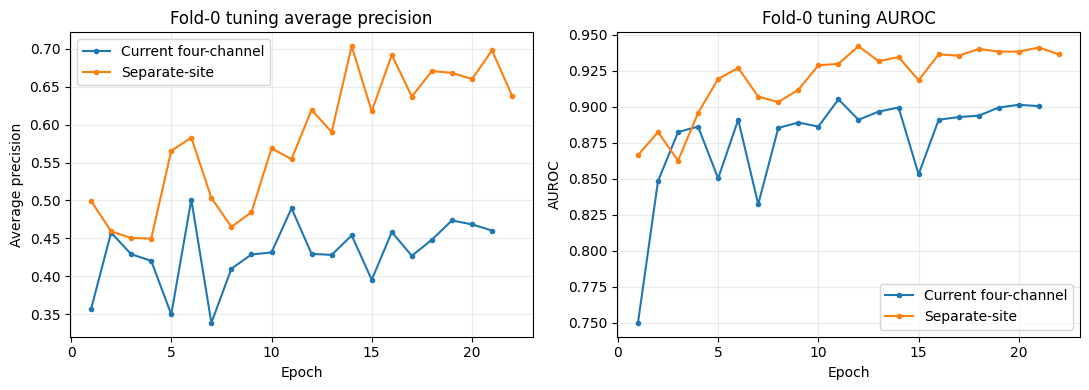

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for architecture, label in [('joint_4ch', 'Current four-channel'), ('shared_site', 'Separate-site')]:
    history = pd.read_csv(MODEL_DIR / 'fold0_seed42' / architecture / 'history.csv')
    axes[0].plot(history['epoch'], history['val_auprc'], marker='o', ms=3, label=label)
    axes[1].plot(history['epoch'], history['val_auroc'], marker='o', ms=3, label=label)
axes[0].set(title='Fold-0 tuning average precision', xlabel='Epoch', ylabel='Average precision')
axes[1].set(title='Fold-0 tuning AUROC', xlabel='Epoch', ylabel='AUROC')
for ax in axes:
    ax.grid(alpha=.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Main comparison: five scoring folds and two starting seeds

A seed controls the random starting weights and training order. Repeating the comparison with another seed checks whether the result depends too much on one lucky start. Average precision is the main measure because only 12% of development patients have HFrEF.

In [5]:
architecture_runs = []
for seed in (42, 2026):
    frame = pd.read_csv(OUTPUT_DIR / f'five_fold_seed{seed}_results.csv')
    frame['seed'] = seed
    architecture_runs.append(frame)
architecture_runs = pd.concat(architecture_runs, ignore_index=True)
fold_view = architecture_runs[['seed', 'scoring_fold', 'architecture', 'auprc', 'auroc', 'recall', 'specificity', 'balanced_accuracy', 'brier']]
display(fold_view.round(3))
two_seed_summary = architecture_runs.groupby('architecture')[['auprc', 'auroc', 'recall', 'specificity', 'balanced_accuracy', 'f1', 'brier', 'calibration_error']].mean()
display(two_seed_summary.round(3))

,seed,scoring_fold,architecture,auprc,auroc,recall,specificity,balanced_accuracy,brier
0,42,0,joint_4ch,0.369,0.853,0.667,0.886,0.777,0.100
1,42,0,shared_site,0.541,0.885,0.750,0.830,0.790,0.144
2,42,1,joint_4ch,0.626,0.845,0.750,0.830,0.790,0.096
3,42,1,shared_site,0.665,0.861,0.667,0.807,0.737,0.088
4,42,2,joint_4ch,0.487,0.825,0.333,0.966,0.650,0.119
5,42,2,shared_site,0.603,0.908,0.417,0.955,0.686,0.110
6,42,3,joint_4ch,0.580,0.917,0.917,0.807,0.862,0.183
7,42,3,shared_site,0.602,0.911,0.917,0.818,0.867,0.142
8,42,4,joint_4ch,0.555,0.924,0.667,0.909,0.788,0.149
9,42,4,shared_site,0.610,0.922,0.750,0.886,0.818,0.159


,auprc,auroc,recall,specificity,balanced_accuracy,f1,brier,calibration_error
architecture,,,,,,,,
joint_4ch,0.531,0.881,0.725,0.882,0.803,0.553,0.127,0.192
shared_site,0.587,0.902,0.733,0.855,0.794,0.525,0.123,0.207


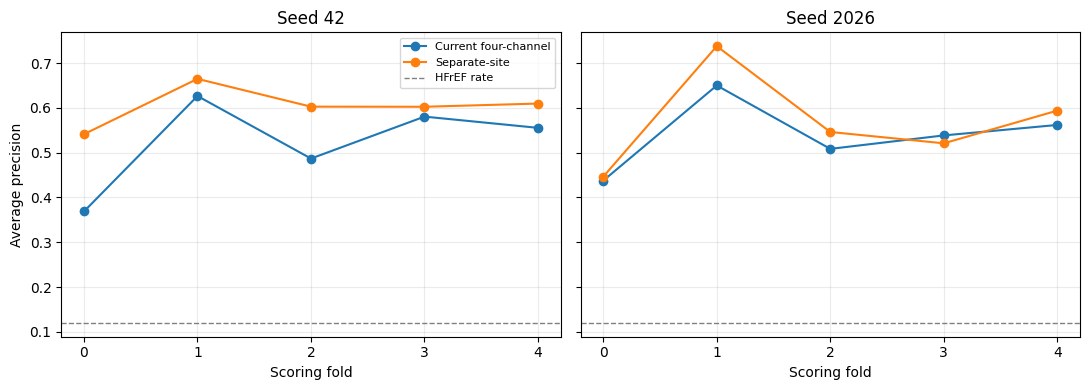

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, seed in zip(axes, (42, 2026)):
    part = architecture_runs[architecture_runs.seed.eq(seed)]
    for architecture, label in [('joint_4ch', 'Current four-channel'), ('shared_site', 'Separate-site')]:
        values = part[part.architecture.eq(architecture)].sort_values('scoring_fold')
        ax.plot(values.scoring_fold, values.auprc, marker='o', label=label)
    ax.axhline(.12, color='gray', ls='--', lw=1, label='HFrEF rate' if seed == 42 else None)
    ax.set(title=f'Seed {seed}', xlabel='Scoring fold', xticks=range(5))
    ax.grid(alpha=.25)
axes[0].set_ylabel('Average precision')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
for seed in (42, 2026):
    print(f'Seed {seed}: separate-site minus current model')
    uncertainty = pd.read_csv(OUTPUT_DIR / f'five_fold_seed{seed}_paired_uncertainty.csv')
    display(uncertainty.round(3))

Seed 42: separate-site minus current model


,metric,difference_shared_minus_joint,ci_low,ci_high,bootstrap_samples
0,auprc,0.081,-0.014,0.154,2000
1,auroc,0.025,-0.008,0.064,2000
2,recall,0.033,-0.050,0.117,2000
3,specificity,-0.020,-0.043,0.002,2000
4,balanced_accuracy,0.006,-0.038,0.053,2000
5,brier,-0.001,-0.011,0.009,2000
6,calibration_error,0.026,0.006,0.043,2000


Seed 2026: separate-site minus current model


,metric,difference_shared_minus_joint,ci_low,ci_high,bootstrap_samples
0,auprc,0.030,-0.035,0.099,2000
1,auroc,0.016,-0.012,0.044,2000
2,recall,-0.017,-0.117,0.083,2000
3,specificity,-0.034,-0.064,-0.005,2000
4,balanced_accuracy,-0.025,-0.076,0.028,2000
5,brier,-0.006,-0.013,0.001,2000
6,calibration_error,0.005,-0.016,0.020,2000


### Architecture decision: promising for ranking, but not ready to replace the current model

Across the ten fold-and-seed runs, the separate-site model improved average precision in 9 runs and gained about 0.055 on average. It also lost about 0.027 specificity and did not improve balanced accuracy overall. Both average-precision uncertainty ranges include zero. This means the ranking gain may be real, but these experiments are too small and variable to establish it.

## Probability calibration

A well-calibrated probability should match what happens in similar patients. For example, among patients given about 0.7 probability, about 70% would have HFrEF in a large, stable dataset. These plots are rough because each fold contains only 12 HFrEF patients. The five scoring folds are combined within each seed, although each fold used a separately trained model and cutoff, so treat the curves as a broad warning rather than a precise calibration estimate.

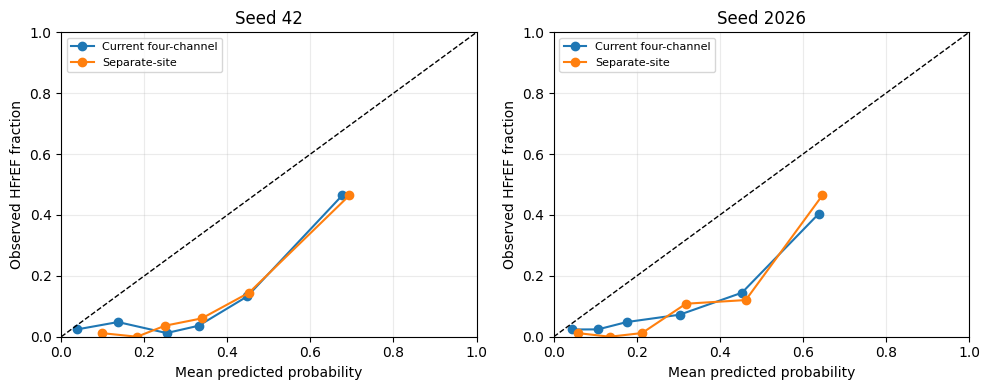

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, seed in zip(axes, (42, 2026)):
    predictions = pd.read_csv(OUTPUT_DIR / f'five_fold_seed{seed}_predictions.csv')
    for architecture, label in [('joint_4ch', 'Current four-channel'), ('shared_site', 'Separate-site')]:
        part = predictions[predictions.Architecture.eq(architecture)]
        observed, predicted = calibration_curve(part.Label, part.Probability, n_bins=6, strategy='quantile')
        ax.plot(predicted, observed, marker='o', label=label)
    ax.plot([0, 1], [0, 1], color='black', ls='--', lw=1)
    ax.set(title=f'Seed {seed}', xlabel='Mean predicted probability', ylabel='Observed HFrEF fraction', xlim=(0, 1), ylim=(0, 1))
    ax.grid(alpha=.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Could heart rate or recording quality be a shortcut?

A simple logistic model was trained using only the measured heart-rate estimates, only recording-quality numbers, or both. It used the same development fold roles. This does not prove a cause. It checks whether these non-waveform summaries already separate the labels enough to be a concern.

In [9]:
audit_dir = OUTPUT_DIR / 'feature_audit'
audit_summary = pd.read_csv(audit_dir / 'simple_predictor_summary.csv')
display(audit_summary[['feature_group', 'auprc_mean', 'auroc_mean', 'recall_mean', 'specificity_mean', 'balanced_accuracy_mean']].round(3))
associations = pd.read_csv(audit_dir / 'deep_score_associations.csv')
associations['absolute_rho'] = associations.spearman_rho.abs()
display(associations.sort_values('absolute_rho', ascending=False)[['seed', 'architecture', 'patient_group', 'measure', 'patients', 'spearman_rho']].head(12).round(3))

,feature_group,auprc_mean,auroc_mean,recall_mean,specificity_mean,balanced_accuracy_mean
0,heart_rate_and_quality,0.404,0.728,0.400,0.895,0.648
1,heart_rate_only,0.206,0.640,0.483,0.732,0.608
2,quality_only,0.383,0.696,0.467,0.893,0.680


,seed,architecture,patient_group,measure,patients,spearman_rho
74,2026,shared_site,HFrEF,mean_longest_constant_run_s,60,-0.319
11,42,joint_4ch,HFrEF,mean_longest_constant_run_s,60,-0.304
37,42,shared_site,all,mean_high_frequency_rms_ratio,500,-0.288
73,2026,shared_site,HFrEF,mean_full_scale_sample_fraction,60,0.284
76,2026,shared_site,HFrEF,quality_flag_site_count,60,0.277
23,42,shared_site,non-HFrEF,mean_high_frequency_rms_ratio,440,-0.262
30,42,shared_site,HFrEF,mean_high_frequency_rms_ratio,60,-0.240
79,2026,shared_site,all,mean_high_frequency_rms_ratio,500,-0.226
70,2026,shared_site,HFrEF,mean_estimated_heart_rate_bpm,60,0.212
10,42,joint_4ch,HFrEF,mean_full_scale_sample_fraction,60,0.203


### Recording-quality observation

Heart rate alone was weak: mean average precision was about 0.206. Recording-quality numbers alone reached about 0.383, compared with a 0.12 HFrEF rate. Heart rate plus quality reached about 0.404. The ECG model scores had only weak-to-moderate links with individual quality measures, with the largest checked absolute rank correlation around 0.32.

The quality result is a warning, not proof that the neural network uses noise. It supports checking acquisition conditions and performance across quality groups before trusting a gain or inventing noise augmentation.

## Does random time cropping help?

The current four-channel model was trained in three ways: the full 30 seconds, the fixed middle 15 seconds, or a random 15-second section on each training visit. Tuning and scoring always used the full 30 seconds. The fixed crop shows whether a change comes from shorter input rather than randomness.

,auprc,auroc,recall,specificity,balanced_accuracy,f1,brier
training_crop,,,,,,,
fixed_15s,0.553,0.877,0.450,0.927,0.689,0.443,0.128
full,0.524,0.873,0.667,0.880,0.773,0.515,0.130
random_15s,0.476,0.881,0.617,0.877,0.747,0.489,0.134


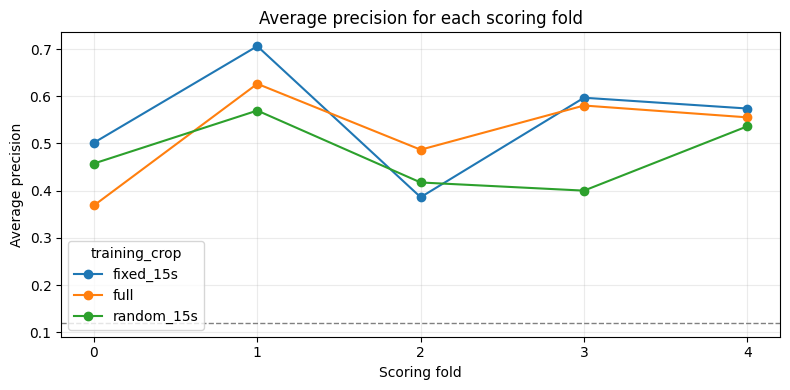

In [10]:
crop_results = pd.read_csv(OUTPUT_DIR / 'crop_comparison_seed42_results.csv')
crop_summary = crop_results.groupby('training_crop')[['auprc', 'auroc', 'recall', 'specificity', 'balanced_accuracy', 'f1', 'brier']].mean()
display(crop_summary.round(3))
plot_data = crop_results.pivot(index='scoring_fold', columns='training_crop', values='auprc')
ax = plot_data.plot(marker='o', figsize=(8, 4))
ax.axhline(.12, color='gray', ls='--', lw=1)
ax.set(title='Average precision for each scoring fold', xlabel='Scoring fold', ylabel='Average precision', xticks=range(5))
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

### Crop decision: reject random 15-second cropping for now

Random cropping reduced mean average precision from about 0.524 to 0.476. The fixed middle crop reached about 0.553, but recall fell from about 0.667 to 0.450, so it missed many more HFrEF patients. Neither result supports using time cropping as the current augmentation.

## Fair cutoff comparison after correcting the model check

**Question:** When both models use the same rule for limiting false HFrEF warnings, does separate-site processing find more HFrEF patients?

A small code problem was found before this comparison. The code checked the model's output shape using tuning patients while the model was still in training mode. This changed its internal running values and used part of its random sequence before training began. It could change the path taken during training. The check now runs in evaluation mode without gradients, then restores the previous mode. The old results are kept as **pre-correction** results. Both models were trained again from the start with seeds 42 and 2026. This issue does not prove why the historical baseline result was different.

We compare two cutoff rules. **Maximum tuning F1** chooses the cutoff with the best F1 on the tuning fold. **At least 90% tuning specificity** first keeps at least 90% of non-HFrEF tuning patients correctly negative, then allows as many positive predictions as possible. Tied scores are handled in a fixed order, and the cutoff is placed midway between adjacent scores when possible. Both rules use tuning patients only. Scoring patients never choose the cutoff.

,seed,model,recall,specificity,precision,f1,balanced_accuracy,auprc,auroc,brier,tuning_specificity
2,42,Four-channel,0.633,0.891,0.461,0.509,0.762,0.534,0.876,0.119,0.909
3,42,Separate-site,0.717,0.902,0.510,0.576,0.809,0.621,0.916,0.112,0.909
6,2026,Four-channel,0.533,0.898,0.412,0.457,0.716,0.482,0.880,0.126,0.909
7,2026,Separate-site,0.633,0.893,0.454,0.513,0.763,0.557,0.886,0.127,0.909


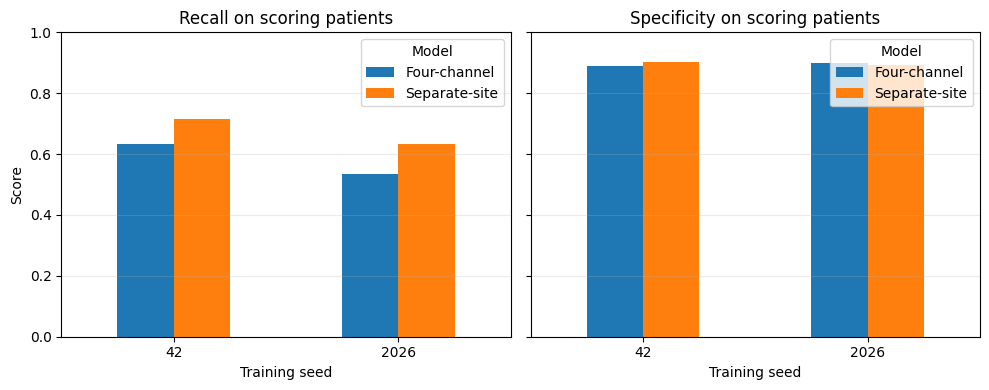

In [11]:
CORRECTED_DIR = OUTPUT_DIR / 'cutoff_reanalysis_corrected'
cutoff_summary = pd.read_csv(CORRECTED_DIR / 'cutoff_summary.csv')
target_summary = cutoff_summary[cutoff_summary['cutoff_rule'].eq('target_90pct_tuning_specificity')].copy()
target_summary['model'] = target_summary['architecture'].replace({'joint_4ch': 'Four-channel', 'shared_site': 'Separate-site'})
summary_columns = ['seed', 'model', 'scoring_recall_mean', 'scoring_specificity_mean', 'scoring_precision_mean', 'scoring_f1_mean', 'scoring_balanced_accuracy_mean', 'scoring_auprc_mean', 'scoring_auroc_mean', 'scoring_brier_mean', 'tuning_specificity_mean']
display(target_summary[summary_columns].rename(columns=lambda name: name.replace('scoring_', '').replace('_mean', '')).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for axis, metric, title in zip(axes, ['scoring_recall_mean', 'scoring_specificity_mean'], ['Recall on scoring patients', 'Specificity on scoring patients']):
    target_summary.pivot(index='seed', columns='model', values=metric).plot(kind='bar', ax=axis, rot=0)
    axis.set(title=title, xlabel='Training seed', ylabel='Score', ylim=(0, 1))
    axis.grid(axis='y', alpha=.25)
    axis.legend(title='Model')
plt.tight_layout()
plt.show()

In [12]:
fold_results = pd.read_csv(CORRECTED_DIR / 'cutoff_results_by_fold.csv')
fold_results['model'] = fold_results['architecture'].replace({'joint_4ch': 'Four-channel', 'shared_site': 'Separate-site'})
fold_columns = ['seed', 'scoring_fold', 'tuning_fold', 'model', 'cutoff_rule', 'cutoff', 'tuning_specificity', 'scoring_recall', 'scoring_specificity', 'scoring_precision', 'scoring_f1', 'scoring_balanced_accuracy', 'scoring_auprc', 'scoring_auroc', 'scoring_brier', 'scoring_tp', 'scoring_fn', 'scoring_tn', 'scoring_fp']
display(fold_results[fold_columns].round(3))

,seed,scoring_fold,tuning_fold,model,cutoff_rule,cutoff,tuning_specificity,scoring_recall,scoring_specificity,scoring_precision,scoring_f1,scoring_balanced_accuracy,scoring_auprc,scoring_auroc,scoring_brier,scoring_tp,scoring_fn,scoring_tn,scoring_fp
0,42,0,1,Four-channel,maximum_tuning_f1,0.615,0.943,0.667,0.875,0.421,0.516,0.771,0.374,0.865,0.176,8,4,77,11
1,42,0,1,Four-channel,target_90pct_tuning_specificity,0.574,0.909,0.750,0.841,0.391,0.514,0.795,0.374,0.865,0.176,9,3,74,14
2,42,0,1,Separate-site,maximum_tuning_f1,0.781,1.000,0.333,0.966,0.571,0.421,0.650,0.531,0.911,0.156,4,8,85,3
3,42,0,1,Separate-site,target_90pct_tuning_specificity,0.651,0.909,0.833,0.875,0.476,0.606,0.854,0.531,0.911,0.156,10,2,77,11
4,42,1,2,Four-channel,maximum_tuning_f1,0.637,0.989,0.500,0.989,0.857,0.632,0.744,0.652,0.859,0.082,6,6,87,1
5,42,1,2,Four-channel,target_90pct_tuning_specificity,0.333,0.909,0.500,0.898,0.400,0.444,0.699,0.652,0.859,0.082,6,6,79,9
6,42,1,2,Separate-site,maximum_tuning_f1,0.107,0.898,0.833,0.864,0.455,0.588,0.848,0.759,0.920,0.065,10,2,76,12
7,42,1,2,Separate-site,target_90pct_tuning_specificity,0.121,0.909,0.833,0.886,0.500,0.625,0.860,0.759,0.920,0.065,10,2,78,10
8,42,2,3,Four-channel,maximum_tuning_f1,0.410,0.886,0.583,0.886,0.412,0.483,0.735,0.476,0.808,0.109,7,5,78,10
9,42,2,3,Four-channel,target_90pct_tuning_specificity,0.494,0.909,0.333,0.966,0.571,0.421,0.650,0.476,0.808,0.109,4,8,85,3


### Main result

With the 90% tuning-specificity rule, separate-site processing improved recall in both repeats: from 63.3% to 71.7% with seed 42, and from 53.3% to 63.3% with seed 2026. Specificity changed only slightly: +1.1 and -0.5 percentage points. Average precision also improved with both seeds. Across the ten scoring fold runs, separate-site recall improved five times, stayed equal five times, and never became worse.

The recall uncertainty range includes zero for seed 42 and touches zero for seed 2026. The repeated seeds and overlapping training folds still use the same 500 patients, so they do not create new independent evidence. The patient-resampling ranges also cannot cover every possible source of uncertainty.

In [13]:
uncertainty = pd.read_csv(CORRECTED_DIR / 'paired_architecture_uncertainty.csv')
target_uncertainty = uncertainty[
    uncertainty['cutoff_rule'].eq('target_90pct_tuning_specificity')
    & uncertainty['metric'].isin(['auprc', 'auroc', 'recall', 'specificity', 'balanced_accuracy'])
].copy()
display(target_uncertainty.round(3))

,seed,cutoff_rule,metric,difference_shared_minus_joint,ci_low,ci_high,bootstrap_samples
7,42,target_90pct_tuning_specificity,auprc,0.087,0.008,0.156,2000
8,42,target_90pct_tuning_specificity,auroc,0.040,0.014,0.070,2000
9,42,target_90pct_tuning_specificity,recall,0.083,-0.017,0.183,2000
10,42,target_90pct_tuning_specificity,specificity,0.011,-0.009,0.032,2000
11,42,target_90pct_tuning_specificity,balanced_accuracy,0.047,-0.002,0.100,2000
21,2026,target_90pct_tuning_specificity,auprc,0.075,-0.001,0.142,2000
22,2026,target_90pct_tuning_specificity,auroc,0.006,-0.027,0.037,2000
23,2026,target_90pct_tuning_specificity,recall,0.100,0.000,0.200,2000
24,2026,target_90pct_tuning_specificity,specificity,-0.005,-0.027,0.018,2000
25,2026,target_90pct_tuning_specificity,balanced_accuracy,0.048,-0.006,0.103,2000


### Does signal quality explain the improvement?

We divided patients into lower, middle, and higher signal-quality groups. Each scoring fold used boundaries calculated from its three training folds. The separate-site improvement was not limited to one clear quality group. Some groups contain very few HFrEF patients, so their recall can change sharply when only one patient changes. Three patients had at least one site where the automatic beat check failed; this group is too small to support a conclusion.

In [14]:
quality = pd.read_csv(CORRECTED_DIR / 'quality_group_summary.csv')
quality_target = quality[quality['Cutoff_Rule'].eq('target_90pct_tuning_specificity')].copy()
regular_quality = quality_target[quality_target['Quality_Measure'].ne('beat_detection_check')]
paired_quality = regular_quality.pivot_table(
    index=['Seed', 'Quality_Measure', 'Quality_Group', 'patients', 'hfref_patients'],
    columns='Architecture', values=['recall', 'specificity']
).reset_index()
paired_quality.columns = ['seed', 'quality_measure', 'quality_group', 'patients', 'hfref_patients', 'joint_recall', 'shared_recall', 'joint_specificity', 'shared_specificity']
paired_quality['recall_change'] = paired_quality['shared_recall'] - paired_quality['joint_recall']
paired_quality['specificity_change'] = paired_quality['shared_specificity'] - paired_quality['joint_specificity']
display(paired_quality[['seed', 'quality_measure', 'quality_group', 'patients', 'hfref_patients', 'recall_change', 'specificity_change']].round(3))

failed = quality_target[quality_target['Quality_Group'].eq('one_or_more_failed')]
display(failed[['Seed', 'Architecture', 'patients', 'hfref_patients', 'non_hfref_patients', 'recall', 'specificity']].round(3))

,seed,quality_measure,quality_group,patients,hfref_patients,recall_change,specificity_change
0,42,mean_baseline_drift_rms_ratio,high,167,13,0.077,0.006
1,42,mean_baseline_drift_rms_ratio,low,167,28,0.143,0.014
2,42,mean_baseline_drift_rms_ratio,middle,166,19,0.000,0.014
3,42,mean_high_frequency_rms_ratio,high,168,18,-0.056,0.013
4,42,mean_high_frequency_rms_ratio,low,168,35,0.114,0.008
5,42,mean_high_frequency_rms_ratio,middle,164,7,0.286,0.013
6,2026,mean_baseline_drift_rms_ratio,high,167,13,0.231,-0.013
7,2026,mean_baseline_drift_rms_ratio,low,167,28,0.143,-0.007
8,2026,mean_baseline_drift_rms_ratio,middle,166,19,-0.053,0.007
9,2026,mean_high_frequency_rms_ratio,high,168,18,0.000,0.033


,Seed,Architecture,patients,hfref_patients,non_hfref_patients,recall,specificity
17,42,joint_4ch,3,1,2,1.0,1.0
25,42,shared_site,3,1,2,0.0,1.0
49,2026,joint_4ch,3,1,2,0.0,1.0
57,2026,shared_site,3,1,2,0.0,1.0


## Decision

Use the **separate-site model as the model to develop next**. It ranked patients better with both seeds, and it found more HFrEF patients at roughly the same specificity when we used the planned 90% tuning-specificity rule. This is stronger and fairer evidence than the earlier comparison.

Keep the old four-channel checkpoint as the historical reference for now. We have not trained one final separate-site model on all development data, and we have not opened the test set. The small number of HFrEF patients means the size of the improvement is still uncertain.

- **Random cropping:** reject for now because average precision became worse.
- **Mild noise:** wait until we know which noise types and strengths are realistic.
- **Extra loss weighting or balanced sampling:** wait because focal loss already gives extra weight to HFrEF examples.
- **Large amplitude changes, time stretching, beat warping, and changing site order:** avoid for now because these changes may create unrealistic signals.

This was the development decision before the community test set was opened. Any later augmentation idea must still be justified and compared using development patients only.

## Later community test check

After the development decision above, the community test evaluation was requested. The separate-site checkpoint was chosen before reading test labels: seed 42, scoring fold 1, which had the highest held-out development average precision among the corrected separate-site checkpoints.

The main comparison gives both models the same cutoff rule: reach at least 90% specificity on that model's development tuning patients, then allow as many positive predictions as possible. No test value chooses a model or cutoff.

In [15]:
community_results = pd.read_csv(OUTPUT_DIR / 'community_test' / 'community_test_results.csv')
community_primary = community_results[community_results['cutoff_rule'].eq('target_90pct_tuning_specificity')].copy()
community_columns = ['model', 'development_cutoff', 'test_recall', 'test_specificity', 'test_precision', 'test_f1', 'test_balanced_accuracy', 'test_auprc', 'test_auroc', 'test_tp', 'test_fn', 'test_tn', 'test_fp']
display(community_primary[community_columns].round(3))

,model,development_cutoff,test_recall,test_specificity,test_precision,test_f1,test_balanced_accuracy,test_auprc,test_auroc,test_tp,test_fn,test_tn,test_fp
2,Notebook 2.1 four-channel,0.498,1.0,0.965,0.556,0.714,0.983,0.967,0.998,5,0,111,4
3,Best separate-site,0.121,1.0,0.878,0.263,0.417,0.939,0.900,0.991,5,0,101,14


### Community test result

The test set has 120 patients, including only 5 HFrEF patients. Both models found all five. The notebook 2.1 model produced 4 false warnings, while the separate-site model produced 14. The notebook 2.1 model also had better average precision and AUROC.

**Keep the notebook 2.1 four-channel model.** The separate-site model was promising during development but did not improve the held-out community test result. With only five HFrEF patients, one patient would change recall by 20 percentage points. Do not use this test result to tune another model.

## Saved files

- `models/ecg_experiments/.../best_model.pt`: the selected checkpoint for that run.
- `history.csv`: training and tuning measures for every epoch.
- `tuning_predictions.csv`: patient scores used to choose the cutoff.
- `scoring_predictions.csv`: separate patient scores used to report performance.
- `settings_and_results.json`: folds, settings, cutoff, metrics, runtime, and model size.
- `analysis_outputs/ecg_experiments/five_fold_*`: combined architecture results, all scored-patient predictions, and patient-resampling uncertainty.
- `analysis_outputs/ecg_experiments/feature_audit/*`: the patient-level heart-rate and quality table, simple-predictor results, and score associations.
- `analysis_outputs/ecg_experiments/crop_comparison_*`: full, fixed-crop, and random-crop results and patient predictions.
- `analysis_outputs/ecg_experiments/five_fold_corrected_seed*`: corrected five-fold results for both models and both seeds.
- `analysis_outputs/ecg_experiments/cutoff_reanalysis_pre_correction/*`: the old saved predictions checked with both cutoff rules.
- `analysis_outputs/ecg_experiments/cutoff_reanalysis_corrected/*`: corrected cutoff results, paired uncertainty, and quality-group checks.
- `analysis_outputs/ecg_experiments/community_test/*`: the fixed model choice, test probabilities, and final test comparison.